### DEMO1: Overview of how I using Gaussian process joint modeling ([GPJM](https://www.pnas.org/doi/10.1073/pnas.1912342117)) framework to generate the synthetic dataset.

This is the first step for the whole pipeline. Before using the real dataset, I want use the synthetic dataset to verify the model first. The method I use should have 2 features: 
1. It can simultaneously generate brain and behavioral signals, simulating the simultaneous measurement of brain and behavioral signal data in subjects. GPJM is based on **latent dynamics** to simultaneously generate brain and behavioral signals, thus meeting this requirement.
2. It can be used to design a classification task. By defining different Latent Dynamics to generate corresponding brain and behavioral signals, it is possible to simulate the corresponding signals produced by subjects under different conditions.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import os
import numpy as np
import gpflow
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load data generator
from GPJMv3_datagen import *

Each label corresponds to a different latent dynamical regime, which later defines a classification task.

In [2]:
# Output directories
project_root = Path(os.getcwd()).resolve().parent
base_dir = project_root / "dataset" / "synthetic_data"
labels = ["label1", "label2", "label3"]

for label in labels:
    (base_dir / label).mkdir(parents=True, exist_ok=True)

print(f"Saving data to: {base_dir}")

Saving data to: F:\TUD\Phd_application\Gao\code_interview\dfnn_demo\dataset\synthetic_data


#### Designing latent dynamics (core idea)

In GPJM, both neural and behavioral observations are generated from **shared latent control signals**.

To simulate different experimental conditions, I define **distinct latent dynamics** for each label.

In [3]:
# Time length
N_t = 100

# Spatial grid
ss = np.array([(x, y, z) for x in range(3) for y in range(3) for z in range(3)], dtype=np.float64)

# Latent dynamics for each label
# Label 1
ts_1 = np.linspace(0, N_t, int(3 * N_t / 2 + 1)).reshape(-1, 1)
cs_1 = np.column_stack([
    1.0 * np.sin(ts_1 / 10 + np.pi / 4),
    1.2 * np.sin(ts_1 / 6)
])

# Label 2
ts_2 = np.linspace(0, 2 * N_t, int(3 * N_t / 2 + 1)).reshape(-1, 1)
cs_2 = np.column_stack([
    3.0 * np.sin(ts_2 / 5 + np.pi / 2) + 0.5,
    2.0 * np.cos(ts_2 / 4 - np.pi / 3)
])

# Label 3
ts_3 = np.linspace(0, 3 * N_t, int(3 * N_t / 2 + 1)).reshape(-1, 1)
cs_3 = np.column_stack([
    np.sin(ts_3 / 6) + np.sin(ts_3 / 12) + 1.5,
    np.sin(ts_3 / 4) - 0.5 + 0.5 * np.sin(ts_3 / 8)
])

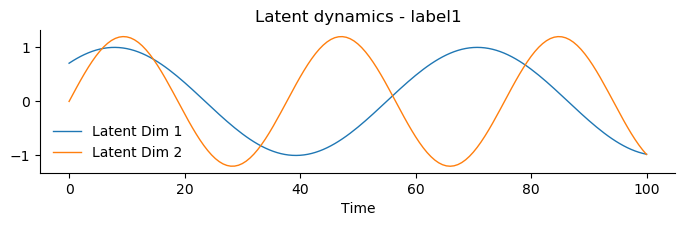

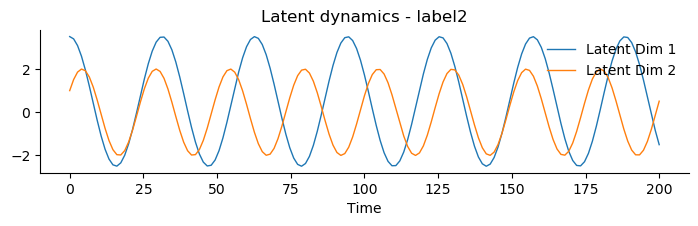

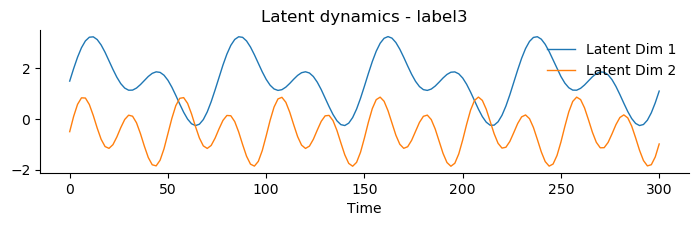

In [4]:
# Plot latent dynamics
latent_sets = [
    ("label1", ts_1, cs_1),
    ("label2", ts_2, cs_2),
    ("label3", ts_3, cs_3),
]

cm = 1 / 2.54
for name, ts, cs in latent_sets:
    fig, ax = plt.subplots(figsize=(18 * cm, 6 * cm))
    ax.plot(ts, cs[:, 0], label="Latent Dim 1", linewidth=1.0)
    ax.plot(ts, cs[:, 1], label="Latent Dim 2", linewidth=1.0)
    ax.set_xlabel("Time")
    ax.set_title(f"Latent dynamics - {name}")
    ax.legend(frameon=False)
    sns.despine()
    fig.tight_layout()
    plt.show()
    plt.close(fig)

#### GPJM model and hyperparameters

Here, I fix the GPJM hyperparameters and vary only the latent dynamics, so that differences in observations are only driven by latent structure.

label1: neural shape (151, 27), behavior shape (151, 1)


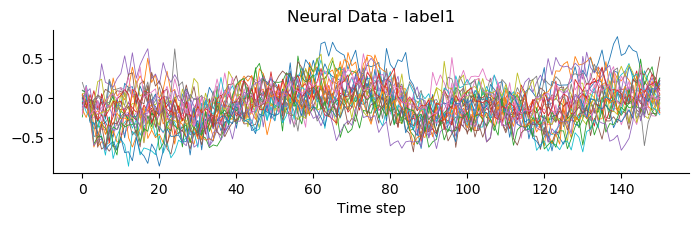

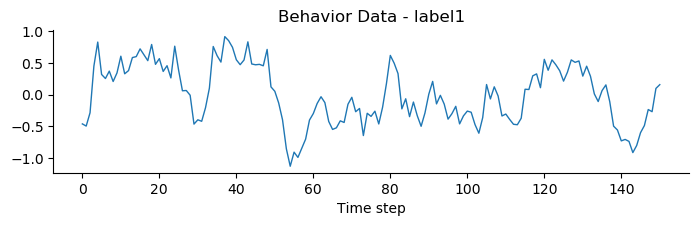

label2: neural shape (151, 27), behavior shape (151, 1)


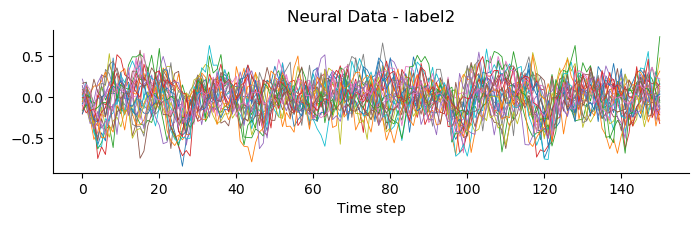

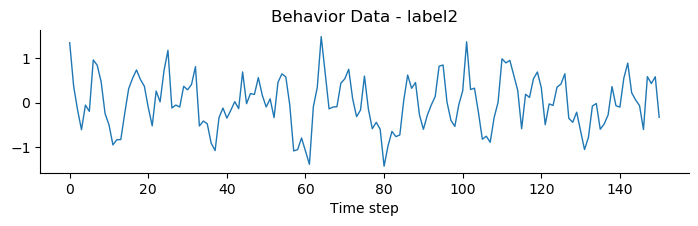

label3: neural shape (151, 27), behavior shape (151, 1)


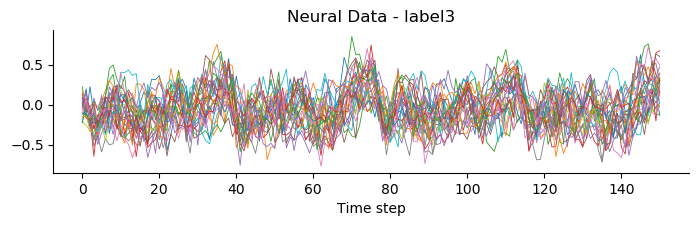

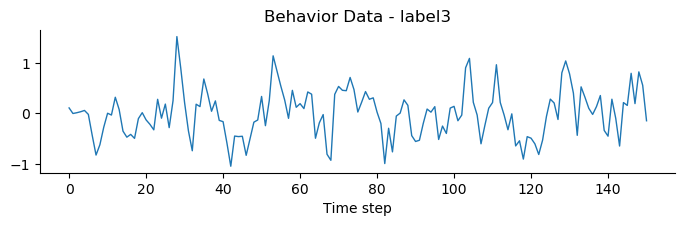

Synthetic data generation complete.


In [5]:
# GPJM hyperparameters
theta_cc = [1, 0.75, 0.75]   # latent kernel
theta_ss = [0.5, 0.75]      # spatial kernel
theta_bb = [0.75, 3, 3]     # behavior kernel

sigma2 = [0.015, 0.015]     # noise levels
n_samp = [1, 1]             # number of samples
seed_val = 1                # fixed seed for reproducibility

# Data generation
for label, ts, cs in zip(
    labels,
    [ts_1, ts_2, ts_3],
    [cs_1, cs_2, cs_3]
):

    yn0, KIn0, yb, KIb, cs_out, Kcc, Kcc_conv, Kss = data_gen(
        ts, ss,
        theta_cc, theta_ss, theta_bb,
        sigma2, n_samp,
        cs=cs,
        seed=seed_val
    )

    yb = yb.reshape(-1, 1)

    print(f"{label}: neural shape {yn0.shape}, behavior shape {yb.shape}")

    out_dir = base_dir / label
    np.save(out_dir / f"neural_data_{label}_{seed_val}.npy", yn0)
    np.save(out_dir / f"behavior_data_{label}_{seed_val}.npy", yb)

    # Plot neural data
    x = np.arange(yn0.shape[0])
    fig, ax = plt.subplots(figsize=(18 * cm, 6 * cm))
    for ch in range(yn0.shape[1]):
        ax.plot(x, yn0[:, ch], linewidth=0.6)

    ax.set_xlabel("Time step")
    ax.set_title(f"Neural Data - {label}")
    sns.despine()
    fig.tight_layout()
    plt.show()  
    plt.close(fig)

    # Plot behavior data
    x = np.arange(yb.shape[0])

    fig, ax = plt.subplots(figsize=(18 * cm, 6 * cm))
    ax.plot(x, yb, linewidth=1.0)

    ax.set_xlabel("Time step")
    ax.set_title(f"Behavior Data - {label}")
    sns.despine()
    fig.tight_layout()
    plt.show()
    plt.close(fig)
print("Synthetic data generation complete.")
